# GFP tagging: which NeuN cells are GFP-positive

> **Pilot notebook.** This explores thresholds on the percentile scale used during the pilot. Production (pipeline B, `fus.cells`) scores cells as **fold over the slice's background** and tags them at **4.05×**; that column is `gfp_fold` in the cells table. See `docs/gfp-cell-tagging.md`.

The crop is a square of side `SIDE_UM` at full resolution, centred on T3 of Mouse 2 `slide04_s3`. Cells are StarDist outlines on NeuN (CY5).

1. **Normalise** the anti-GFP stain (TRITC) over the whole section: 0 = its 1st percentile over tissue, 1 = its 99.9th. The scale is linear, so a bright cell can go above 1.
2. **Score** each cell by its mean normalised GFP over its pixels.
3. **Tag** cells with a mean above `THRESHOLD` as GFP+.

`THRESHOLD` can be a number, or one of three data-driven choices:

| choice | how | character |
|---|---|---|
| `"log_otsu"` (first pass) | Otsu split of the cell scores on a log scale | sits in the valley between the background and plume populations |
| `"reference"` | 99th percentile of random cell-shaped patches in tissue > 1.5 mm from every target | permissive: takes in the plume's dim halo |
| `"otsu"` | Otsu split on a linear scale | strict: cuts into the plume itself |

Method: `gfp_tagging.py`. The first code cell makes any missing input (crop → `make_crop.py`, cells → `run_stardist.py`, scores → `gfp_tagging.py`); a 3 mm crop takes ~2 min the first time.

In [1]:
%gui qt
import json
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import napari
import numpy as np
import pandas as pd
import tifffile
from napari.utils.colormaps import DirectLabelColormap

SIDE_UM = 3000   # 500, 1000 or 3000 (other sizes are made on first run)

STEM = f"mouse02_slide04_s3_T3_{SIDE_UM}um"
CROP = Path(f"{STEM}.ome.tif")
LABELS = Path(f"results/{STEM}_stardist_labels.tif")
CELLS = Path(f"results/{STEM}_gfp_cells.csv")
SUMMARY = Path(f"results/{STEM}_gfp_threshold.json")
PROJECT = Path("..").resolve()

steps = [
    (CROP, [PROJECT / ".venv/bin/python", "make_crop.py", str(SIDE_UM)]),
    (LABELS, [".venv-stardist/bin/python", "run_stardist.py", str(CROP)]),
    (CELLS, [PROJECT / ".venv/bin/python", "gfp_tagging.py", str(CROP)]),
]
stale = CELLS.exists() and "threshold_log_otsu" not in SUMMARY.read_text()  # old scoring method
for output, command in steps:
    if not output.exists() or (output == CELLS and stale):
        print("making", output)
        subprocess.run([str(c) for c in command], check=True, capture_output=True)

cells = pd.read_csv(CELLS)
summary = json.loads(SUMMARY.read_text())
ref_file = Path(f"results/{STEM}_gfp_reference.csv")
reference = pd.read_csv(ref_file).gfp_mean if ref_file.exists() else None
choices = {"log_otsu": summary["threshold_log_otsu"], "otsu": summary["threshold_otsu"]}
if summary["threshold_reference"] is not None:
    choices["reference"] = summary["threshold_reference"]
print(f"{len(cells):,} cells · normalised over the section: 0 = {summary['normalisation']['lo']}, "
      f"1 = {summary['normalisation']['hi']} raw counts")
for name, t in choices.items():
    print(f"  {name:9s} threshold {t:.3f} -> {(cells.gfp_mean > t).mean():.1%} GFP+")

16,723 cells · normalised over the section: 0 = 70.0, 1 = 15671.0 raw counts
  log_otsu  threshold 0.058 -> 28.2% GFP+
  otsu      threshold 0.261 -> 12.0% GFP+
  reference threshold 0.021 -> 52.1% GFP+


threshold 0.058: 4,721 of 16,723 cells GFP+ (28.2%)


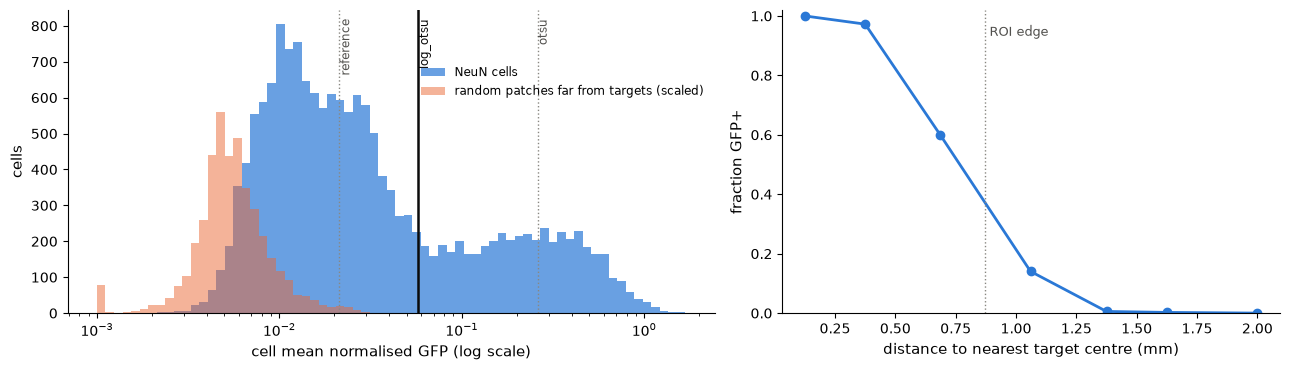

,fraction GFP+,cells
dist_T_mm,,
"(0.0, 0.25]",1.000,308
"(0.25, 0.5]",0.972,1124
"(0.5, 0.87]",0.601,3949
"(0.87, 1.25]",0.140,6593
"(1.25, 1.5]",0.006,3235
"(1.5, 1.75]",0.002,1264
"(1.75, 2.25]",0.000,250


In [2]:
THRESHOLD = "log_otsu"   # or "reference", "otsu", or a number such as 0.1

t = choices[THRESHOLD] if isinstance(THRESHOLD, str) else float(THRESHOLD)
cells["gfp_positive"] = cells.gfp_mean > t
print(f"threshold {t:.3f}: {int(cells.gfp_positive.sum()):,} of {len(cells):,} cells GFP+ "
      f"({cells.gfp_positive.mean():.1%})")

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13, 3.8), gridspec_kw={"width_ratios": [1.3, 1]})
bins = np.logspace(-3, np.log10(max(cells.gfp_mean.max(), 1.0)), 70)
ax.hist(cells.gfp_mean.clip(lower=1e-3), bins=bins, color="#2a78d6", alpha=0.7, label="NeuN cells")
if reference is not None:
    ax.hist(reference.clip(lower=1e-3), bins=bins, color="#eb6834", alpha=0.5,
            weights=np.full(len(reference), len(cells) / len(reference) * 0.25),
            label="random patches far from targets (scaled)")
for name, value in choices.items():
    ax.axvline(value, color="#0b0b0b" if value == t else "#898781",
               linewidth=1.8 if value == t else 1, linestyle="-" if value == t else ":")
    ax.text(value, ax.get_ylim()[1] * 0.97, f" {name}", rotation=90, va="top", fontsize=8.5,
            color="#0b0b0b" if value == t else "#52514e")
ax.set_xscale("log")
ax.set_xlabel("cell mean normalised GFP (log scale)", fontsize=11)
ax.set_ylabel("cells", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, fontsize=8.5, loc="upper right", bbox_to_anchor=(1, 0.85))

edges = np.array([0, 0.25, 0.5, 0.87, 1.25, 1.5, 1.75, 2.25])
band = pd.cut(cells.dist_T_mm, edges)
profile = cells.groupby(band, observed=True).gfp_positive.agg(["mean", "size"])
ax2.plot([(b.left + b.right) / 2 for b in profile.index], profile["mean"], marker="o",
         color="#2a78d6", linewidth=2)
ax2.axvline(0.87, color="#898781", linestyle=":", linewidth=1)
ax2.text(0.89, 0.97, "ROI edge", fontsize=9, color="#52514e", va="top")
ax2.set_ylim(0, 1.02)
ax2.set_xlabel("distance to nearest target centre (mm)", fontsize=11)
ax2.set_ylabel("fraction GFP+", fontsize=11)
ax2.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
display(profile.rename(columns={"mean": "fraction GFP+", "size": "cells"}).round(3))

In [3]:
# napari: GFP shown on the same 0-1 scale as the scores; yellow = GFP+, magenta = GFP-.
with tifffile.TiffFile(CROP) as tf:
    image = tf.asarray()
    meta = tf.ome_metadata
px_um = float(meta.split('PhysicalSizeX="', 1)[1].split('"', 1)[0])
channels = [c.split('Name="', 1)[1].split('"', 1)[0] for c in meta.split("<Channel ")[1:]]
labels = tifffile.imread(LABELS)
lo, hi = summary["normalisation"]["lo"], summary["normalisation"]["hi"]

STYLE = {  # name, colormap, visible, opacity
    "CY5":   ("NeuN (CY5)", "gray", True, 0.4),
    "TRITC": ("GFP stain (TRITC)", "green", True, 1.0),
    "DAPI":  ("DAPI", "blue", False, 1.0),
    "FITC":  ("native GFP (FITC)", "yellow", False, 1.0),
}
viewer = napari.Viewer(title=f"GFP tagging — {STEM}")
for i, ch in enumerate(channels):
    name, cmap, visible, opacity = STYLE.get(ch, (ch, "gray", False, 1.0))
    limits = (lo, hi) if ch == "TRITC" else tuple(np.percentile(image[i][::8, ::8], [1, 99.8]))
    viewer.add_image(image[i], name=name, colormap=cmap, blending="additive", visible=visible,
                     opacity=opacity, contrast_limits=limits, scale=(px_um, px_um), units="um")

colours = {None: "gray", 0: "transparent"}
colours.update({int(l): ("yellow" if p else "magenta") for l, p in zip(cells.label, cells.gfp_positive)})
layer = viewer.add_labels(labels, name=f"cells: GFP+ {int(cells.gfp_positive.sum()):,} (t = {t:.3f})",
                          scale=(px_um, px_um), units="um")
layer.colormap = DirectLabelColormap(color_dict=colours)
layer.contour = 2
viewer.canvas.overlays.scale_bar.visible = True

To try a different threshold, change `THRESHOLD` and re-run the last two cells; each run adds a fresh outline layer. Zoom in to see outlines: the 3 mm crop has ~17,000 cells.